In [1]:
import pandas as pd
from datetime import datetime

from freeze_thaw.data_preparation.general import align_timestamps_then_label, collect_cleaned_data
from freeze_thaw.config import config as c
from freeze_thaw.config import StationName
from freeze_thaw.evaluation.metrics import formatted_cm, calculate_f1_scores
from freeze_thaw.data_understanding.visualization import plot_with_labels, plot_temp_differences

# Assess Methodology

A key assumption in this project is that a single point measurement from an ISMN station can be used to benchmark an area measurement from space-based sensors. This may be a massive leap since the ASCAT and ERA5 measurements cover areas over 100 km$^2$. The goal of this notebook is to compare the ERA5 and ISMN soil temperature measurements to understand the difference between the two methods.

Additionally, this notebook will visualize the separation of ASCAT backscatter measurements according to class labels derived from the ISMN data. Ideally, the backscatter data will clearly separate into three clusters.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*
3. **Summary**
4. **Conclusions**
---

## 1. Setup

### 1.1 Variables

In [2]:
start_date = datetime(2015, 1, 1)
end_date = datetime(2016, 1, 1)

ascat_var_name = "backscatter40"
era5_var_name = "stl1"

ascat_y_label = "40° Normalized Backscatter (dB)"
era5_y_label = "ERA5 stl1 (\u00B0C)"

ascat_x_label = "ISMN Soil Temperature (\u00B0C)"
general_x_label = "Timestamp"

summary_df = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

In [3]:
aberdeen_dfs = collect_cleaned_data(StationName.ABERDEEN, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
aberdeen_ascat_df, aberdeen_era5_df = align_timestamps_then_label(aberdeen_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

aberdeen_ascat_df = aberdeen_ascat_df.dropna()
aberdeen_era5_df = aberdeen_era5_df.dropna()

#### ASCAT

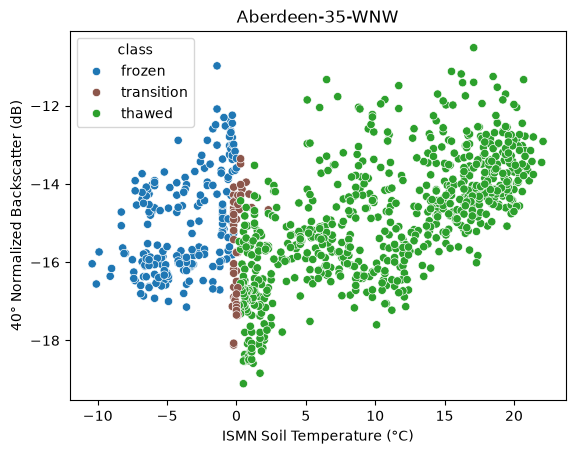

In [4]:
axes = plot_with_labels(aberdeen_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.ABERDEEN)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

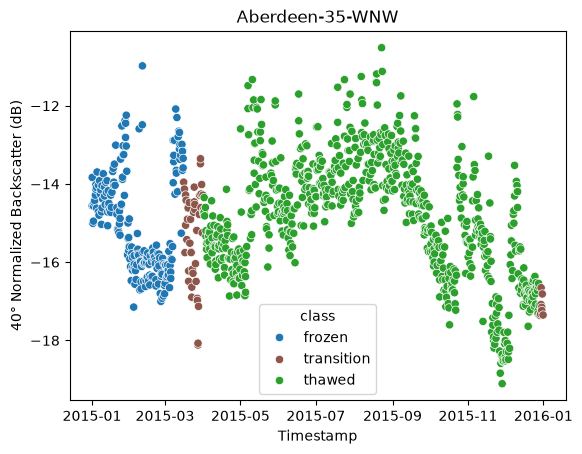

In [5]:
axes = plot_with_labels(aberdeen_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.ABERDEEN)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [6]:
aberdeen_macro_f1, aberdeen_transition_f1 = calculate_f1_scores(aberdeen_era5_df["class"], aberdeen_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.ABERDEEN, aberdeen_macro_f1, aberdeen_transition_f1]

formatted_cm(aberdeen_era5_df["class"], aberdeen_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,2878,869,197
transition,350,153,311
thawed,759,531,9233


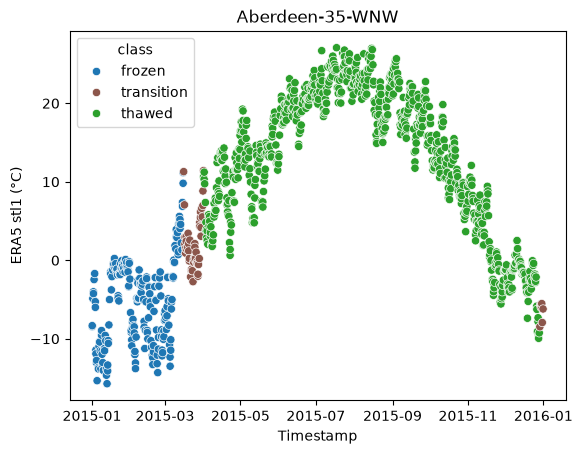

In [7]:
axes = plot_with_labels(aberdeen_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.ABERDEEN)
axes.set_ylabel(era5_y_label)
axes = axes.set_xlabel(general_x_label)

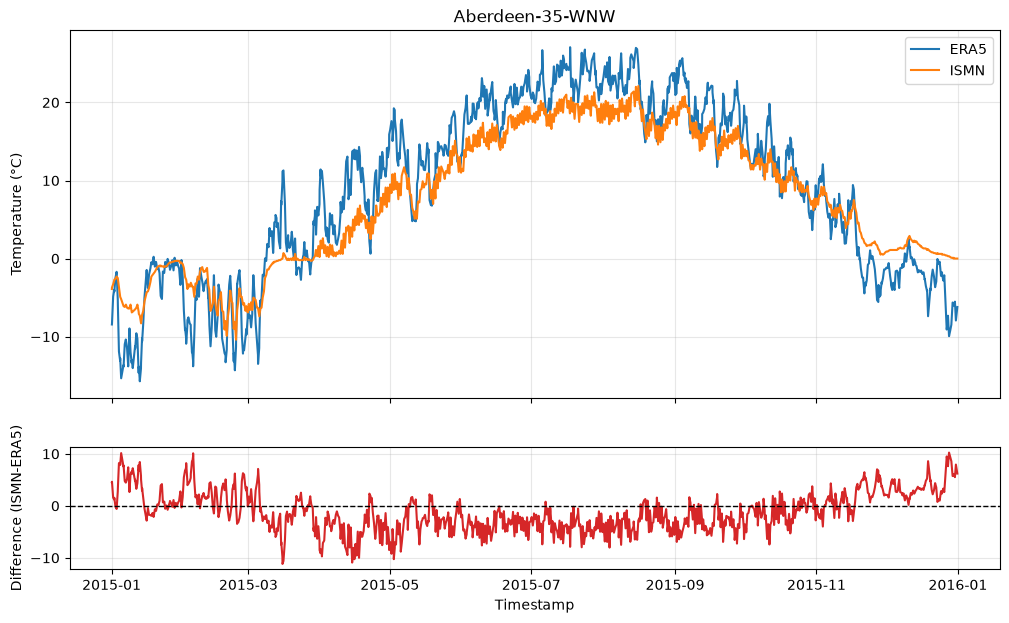

In [8]:
axes = plot_temp_differences(aberdeen_era5_df, StationName.ABERDEEN, start_date, end_date)

### 2.2 Jamestown-38-WSW

In [9]:
jamestown_dfs = collect_cleaned_data(StationName.JAMESTOWN, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
jamestown_ascat_df, jamestown_era5_df = align_timestamps_then_label(jamestown_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

jamestown_ascat_df = jamestown_ascat_df.dropna()
jamestown_era5_df = jamestown_era5_df.dropna()

#### ASCAT

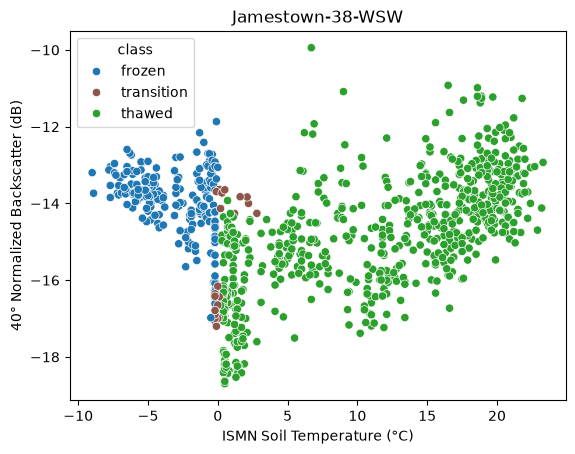

In [10]:
axes = plot_with_labels(jamestown_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.JAMESTOWN)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

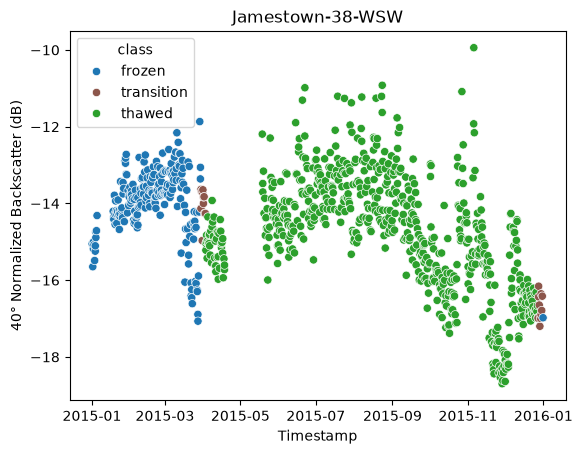

In [11]:
axes = plot_with_labels(jamestown_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.JAMESTOWN)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [12]:
jamestown_macro_f1, jamestown_transition_f1 = calculate_f1_scores(jamestown_era5_df["class"], jamestown_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.JAMESTOWN, jamestown_macro_f1, jamestown_transition_f1]

formatted_cm(jamestown_era5_df["class"], jamestown_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,2961,964,351
transition,306,95,184
thawed,773,476,8898


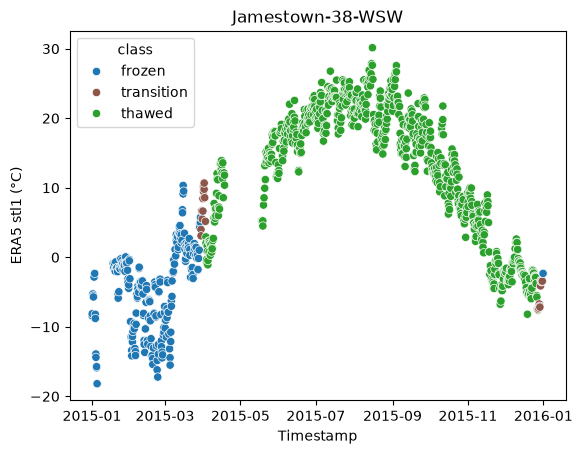

In [13]:
axes = plot_with_labels(jamestown_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.JAMESTOWN)
axes.set_ylabel(era5_y_label)
axes = axes.set_xlabel(general_x_label)

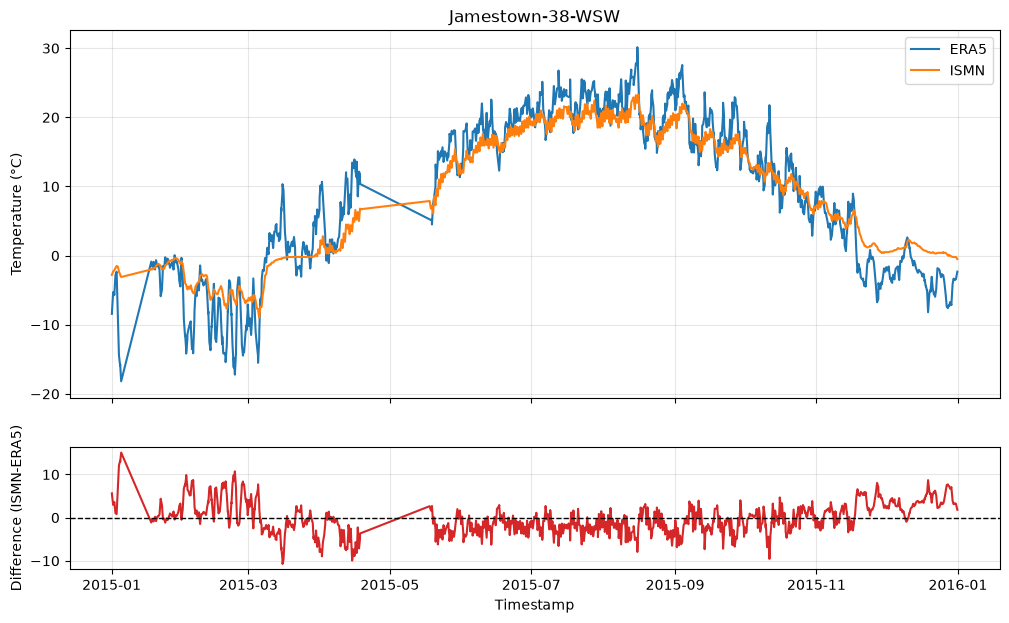

In [14]:
axes = plot_temp_differences(jamestown_era5_df, StationName.JAMESTOWN, start_date, end_date)

### 2.3 Gobblers Knob

In [15]:
gobblers_knob_dfs = collect_cleaned_data(StationName.GOBBLERS_KNOB, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
gobblers_knob_ascat_df, gobblers_knob_era5_df = align_timestamps_then_label(gobblers_knob_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

gobblers_knob_ascat_df = gobblers_knob_ascat_df.dropna()
gobblers_knob_era5_df = gobblers_knob_era5_df.dropna()

#### ASCAT

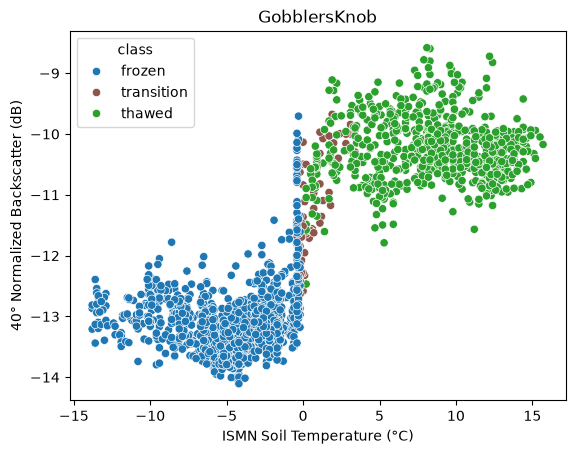

In [16]:
axes = plot_with_labels(gobblers_knob_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.GOBBLERS_KNOB)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

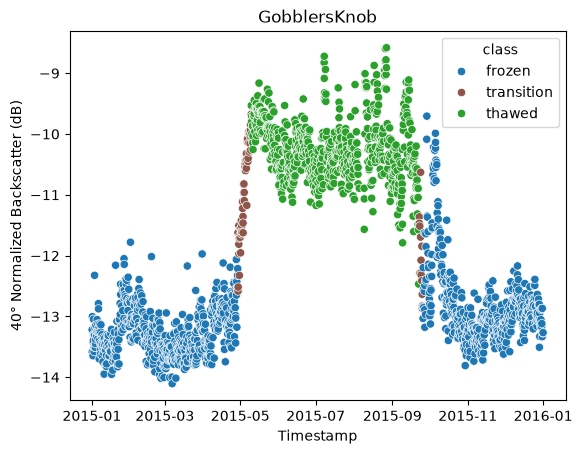

In [17]:
axes = plot_with_labels(gobblers_knob_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.GOBBLERS_KNOB)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [18]:
gobblers_knob_macro_f1, gobblers_knob_transition_f1 = calculate_f1_scores(gobblers_knob_era5_df["class"],
                                                                          gobblers_knob_era5_df["pred"],
                                                                          c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.GOBBLERS_KNOB, gobblers_knob_macro_f1, gobblers_knob_transition_f1]

formatted_cm(gobblers_knob_era5_df["class"], gobblers_knob_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,14038,3592,291
transition,257,376,531
thawed,89,310,10612


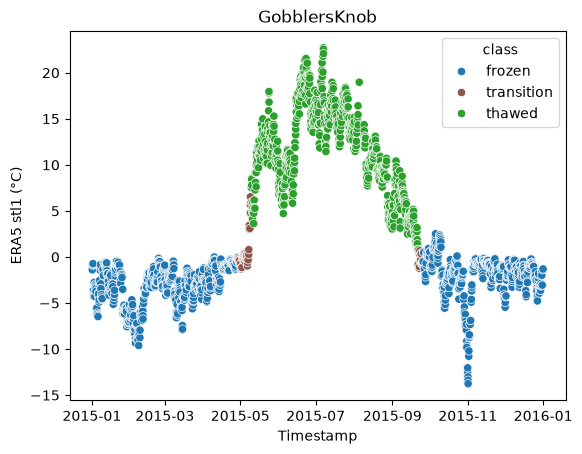

In [19]:
axes = plot_with_labels(gobblers_knob_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.GOBBLERS_KNOB)
axes.set_ylabel(era5_y_label)
axes = axes.set_xlabel(general_x_label)

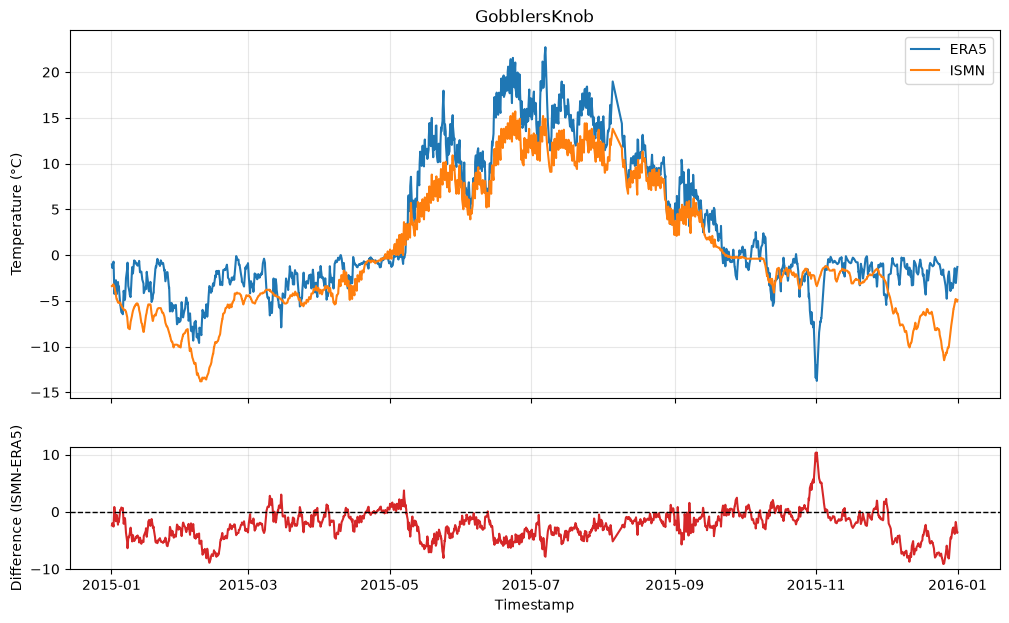

In [20]:
axes = plot_temp_differences(gobblers_knob_era5_df, StationName.GOBBLERS_KNOB, start_date, end_date)

### 2.4 Nenana

In [21]:
nenana_dfs = collect_cleaned_data(StationName.NENANA, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
nenana_ascat_df, nenana_era5_df = align_timestamps_then_label(nenana_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

nenana_ascat_df = nenana_ascat_df.dropna()
nenana_era5_df = nenana_era5_df.dropna()

#### ASCAT

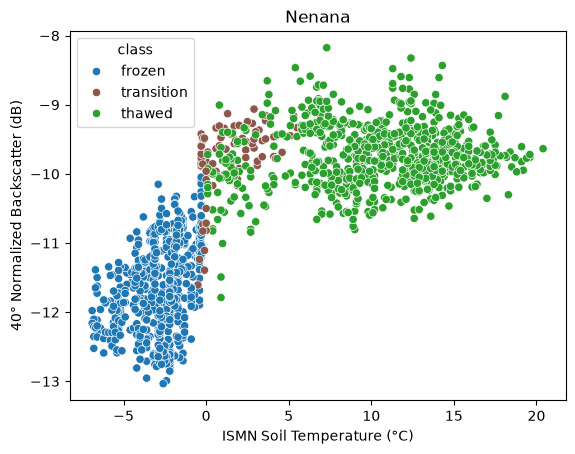

In [22]:
axes = plot_with_labels(nenana_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.NENANA)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

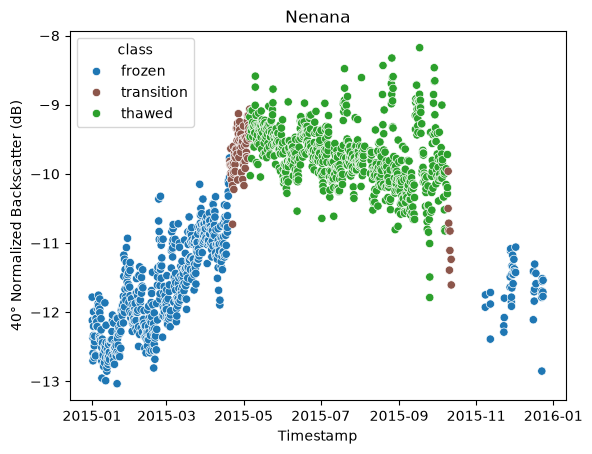

In [23]:
axes = plot_with_labels(nenana_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.NENANA)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [24]:
nenana_macro_f1, nenana_transition_f1 = calculate_f1_scores(nenana_era5_df["class"], nenana_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.NENANA, nenana_macro_f1, nenana_transition_f1]

formatted_cm(nenana_era5_df["class"], nenana_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,8745,1376,779
transition,120,60,678
thawed,246,314,8181


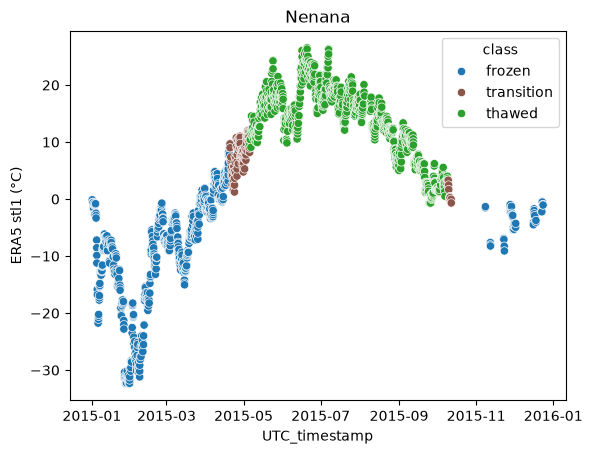

In [25]:
axes = plot_with_labels(nenana_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.NENANA)
axes = axes.set_ylabel(era5_y_label)

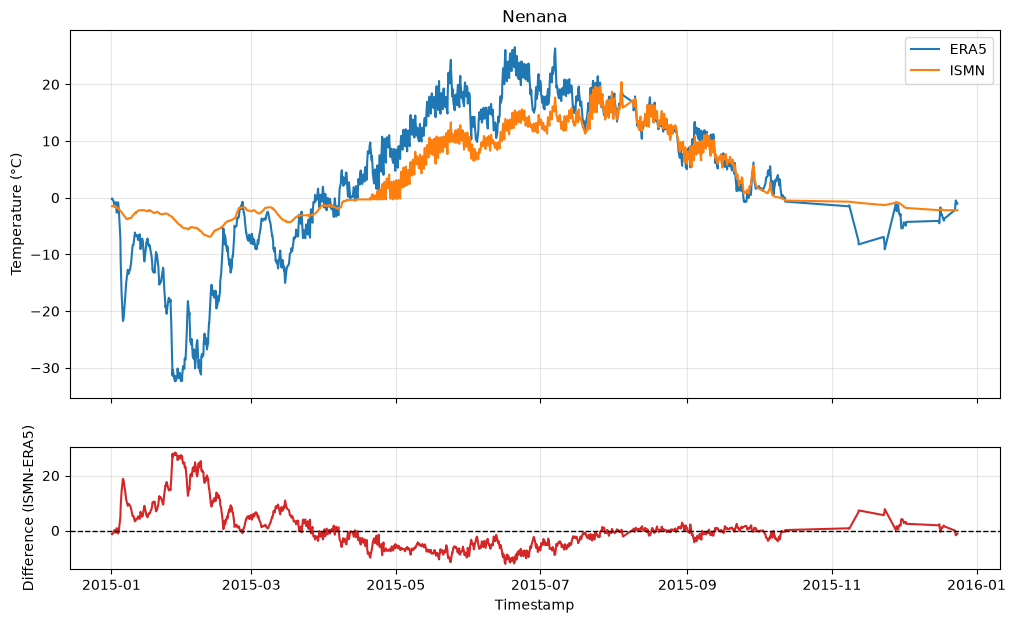

In [26]:
axes = plot_temp_differences(nenana_era5_df, StationName.NENANA, start_date, end_date)

## 2.5 L23

In [27]:
L23_dfs = collect_cleaned_data(StationName.L23, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
L23_ascat_df, L23_era5_df = align_timestamps_then_label(L23_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

L23_ascat_df = L23_ascat_df.dropna()
L23_era5_df = L23_era5_df.dropna()

#### ASCAT

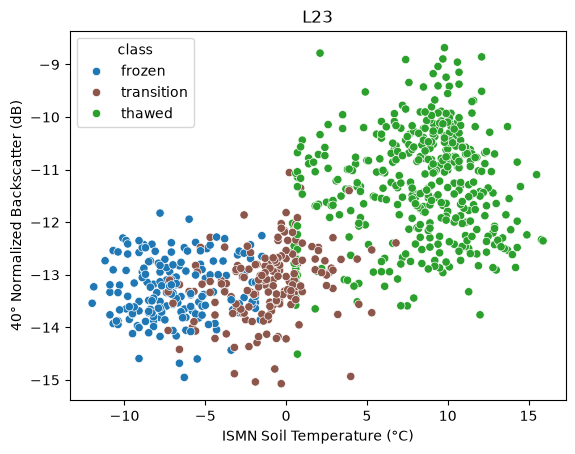

In [28]:
axes = plot_with_labels(L23_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.L23)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

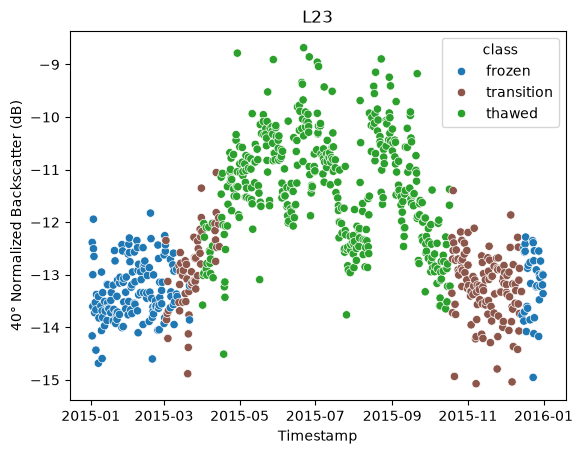

In [29]:
axes = plot_with_labels(L23_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.L23)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [30]:
L23_macro_f1, L23_transition_f1 = calculate_f1_scores(L23_era5_df["class"], L23_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.L23, L23_macro_f1, L23_transition_f1]

formatted_cm(L23_era5_df["class"], L23_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,990,0,0
transition,767,28,0
thawed,340,224,1591


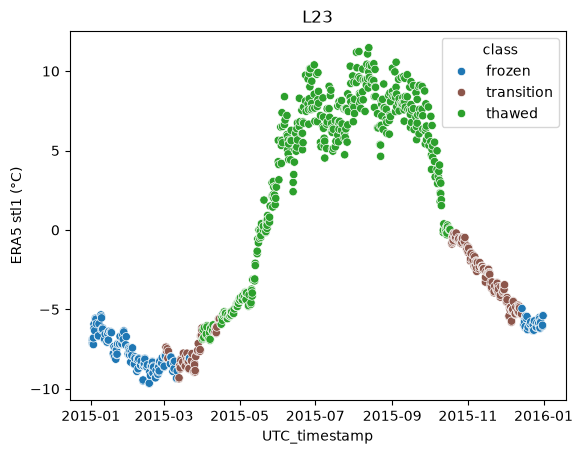

In [31]:
axes = plot_with_labels(L23_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.L23)
axes = axes.set_ylabel(era5_y_label)

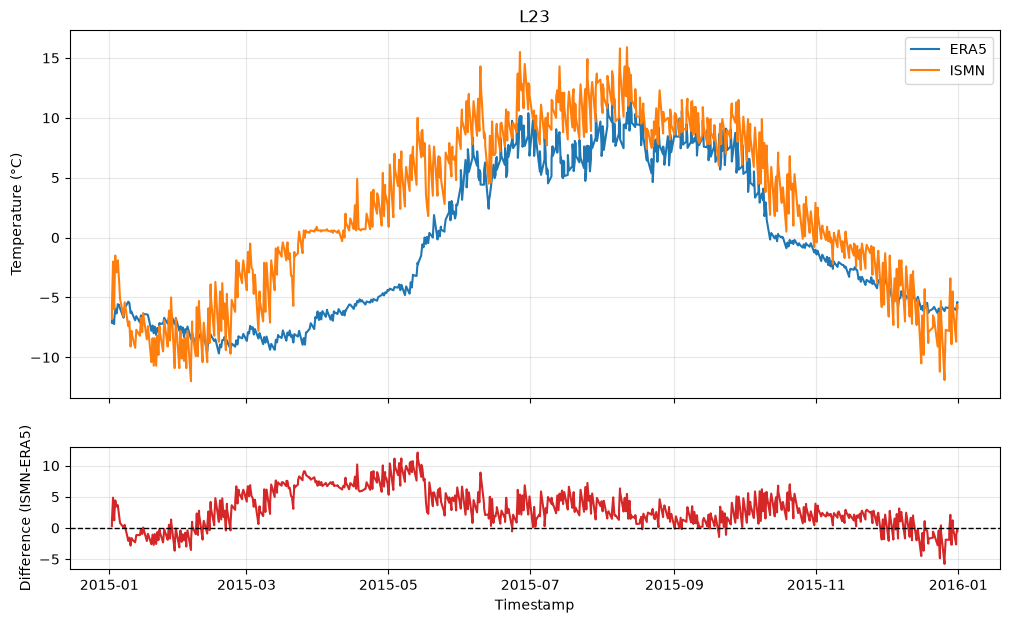

In [32]:
axes = plot_temp_differences(L23_era5_df, StationName.L23, start_date, end_date)

### 2.6 L38

In [33]:
L38_dfs = collect_cleaned_data(StationName.L38, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
L38_ascat_df, L38_era5_df = align_timestamps_then_label(L38_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

L38_ascat_df = L38_ascat_df.dropna()
L38_era5_df = L38_era5_df.dropna()

#### ASCAT

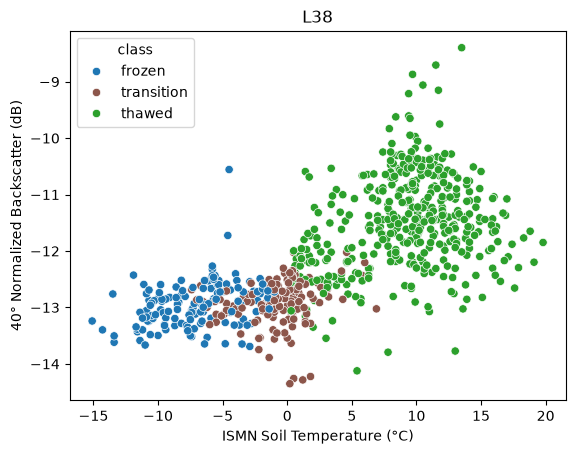

In [34]:
axes = plot_with_labels(L38_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.L38)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

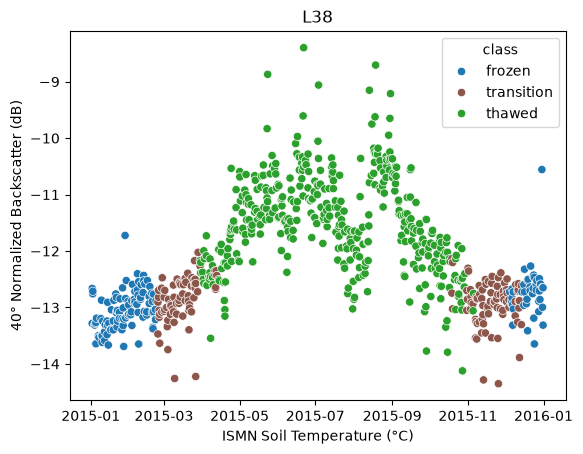

In [35]:
axes = plot_with_labels(L38_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.L38)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

#### ERA5

In [36]:
L38_macro_f1, L38_transition_f1 = calculate_f1_scores(L38_era5_df["class"], L38_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.L38, L38_macro_f1, L38_transition_f1]

formatted_cm(L38_era5_df["class"], L38_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,759,0,0
transition,879,14,0
thawed,283,295,1700


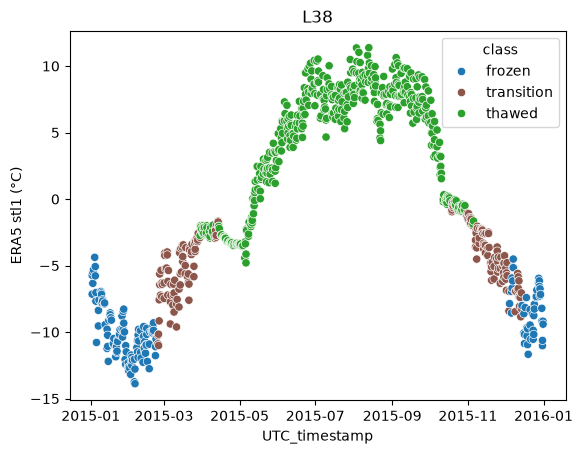

In [37]:
axes = plot_with_labels(L38_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.L38)
axes = axes.set_ylabel(era5_y_label)

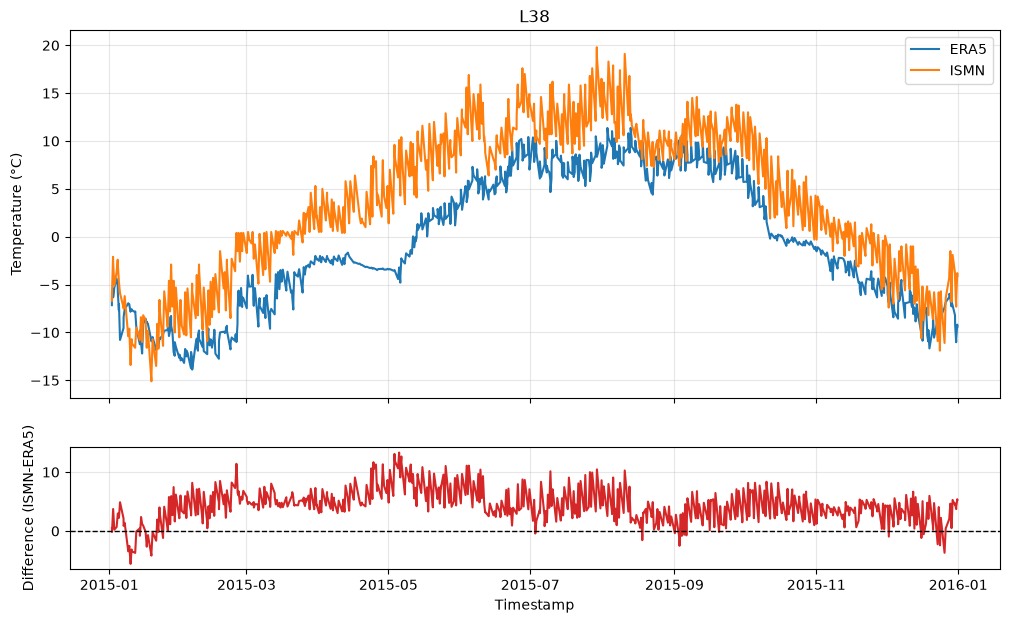

In [38]:
axes = plot_temp_differences(L38_era5_df, StationName.L38, start_date, end_date)

## 2.7 NST-07

In [39]:
NST_07_dfs = collect_cleaned_data(StationName.NST_07, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
NST_07_ascat_df, NST_07_era5_df = align_timestamps_then_label(NST_07_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

NST_07_ascat_df = NST_07_ascat_df.dropna()
NST_07_era5_df = NST_07_era5_df.dropna()

#### ASCAT

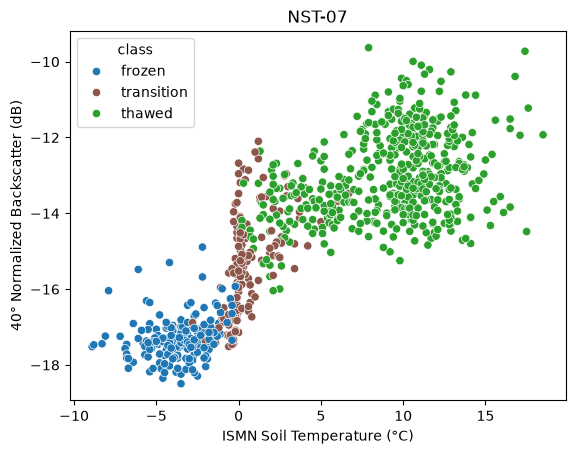

In [40]:
axes = plot_with_labels(NST_07_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.NST_07)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

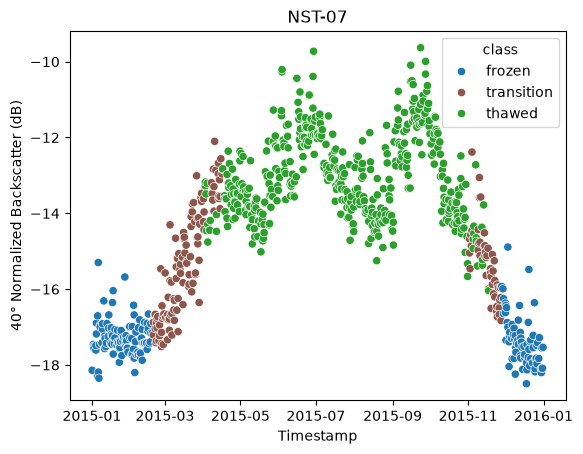

In [41]:
axes = plot_with_labels(NST_07_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.NST_07)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [42]:
NST_07_macro_f1, NST_07_transition_f1 = calculate_f1_scores(NST_07_era5_df["class"], NST_07_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.NST_07, NST_07_macro_f1, NST_07_transition_f1]

formatted_cm(NST_07_era5_df["class"], NST_07_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,1296,0,0
transition,519,258,63
thawed,89,242,3022


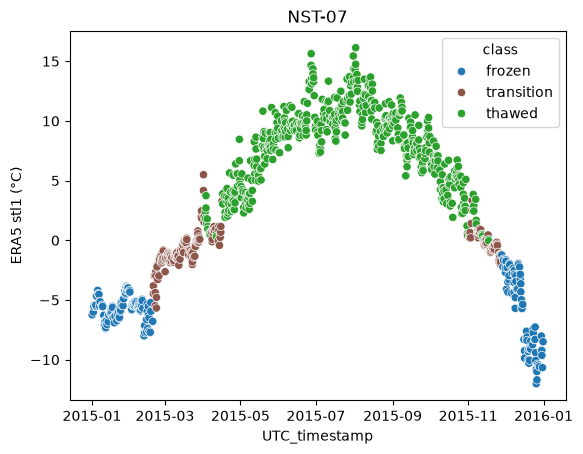

In [43]:
axes = plot_with_labels(NST_07_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.NST_07)
axes = axes.set_ylabel(era5_y_label)

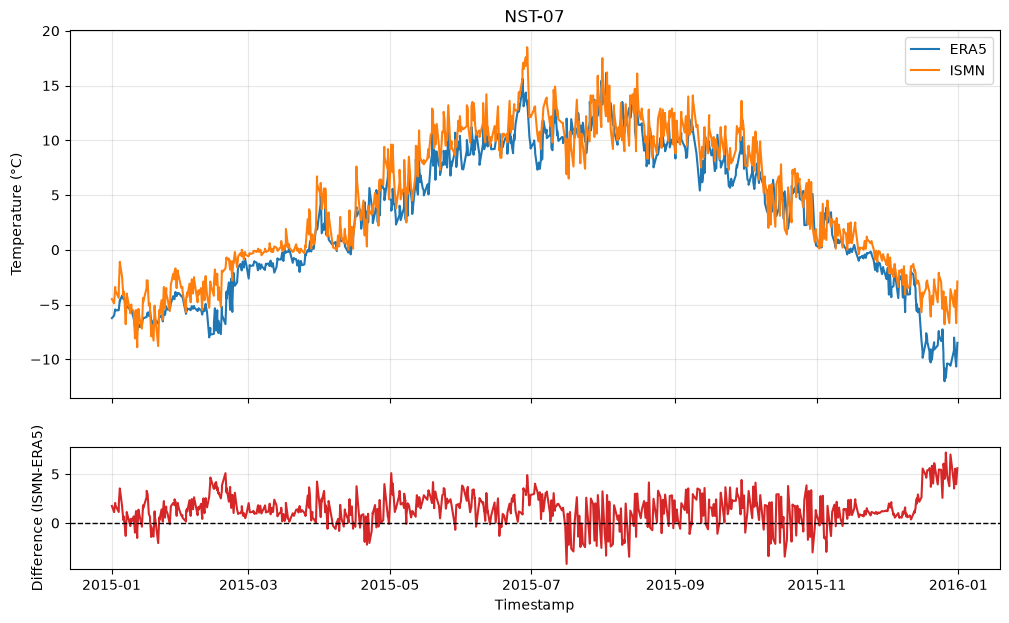

In [44]:
axes = plot_temp_differences(NST_07_era5_df, StationName.NST_07, start_date, end_date)

### 2.8 NST-09

In [45]:
NST_09_dfs = collect_cleaned_data(StationName.NST_09, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
NST_09_ascat_df, NST_09_era5_df = align_timestamps_then_label(NST_09_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

NST_09_ascat_df = NST_09_ascat_df.dropna()
NST_09_era5_df = NST_09_era5_df.dropna()

#### ASCAT

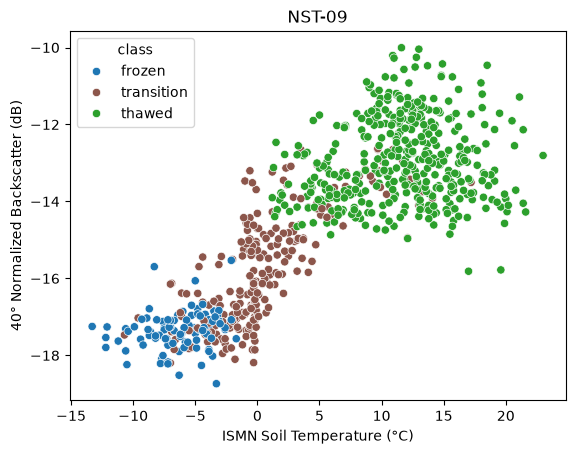

In [46]:
axes = plot_with_labels(NST_09_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.NST_09)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

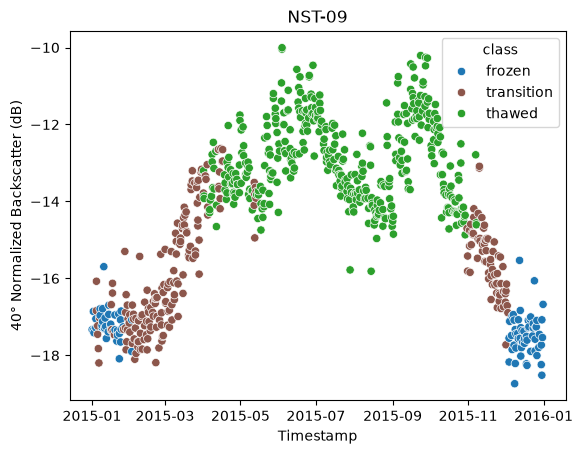

In [47]:
axes = plot_with_labels(NST_09_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.NST_09)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [48]:
NST_09_macro_f1, NST_09_transition_f1 = calculate_f1_scores(NST_09_era5_df["class"], NST_09_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.NST_09, NST_09_macro_f1, NST_09_transition_f1]

formatted_cm(NST_09_era5_df["class"], NST_09_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,1091,0,0
transition,884,251,46
thawed,212,274,2968


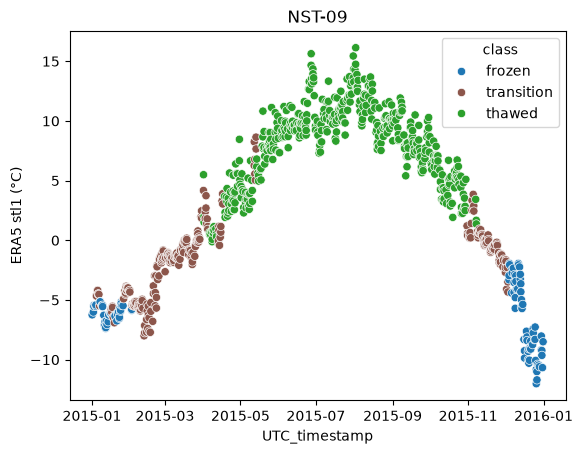

In [49]:
axes = plot_with_labels(NST_09_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.NST_09)
axes = axes.set_ylabel(era5_y_label)

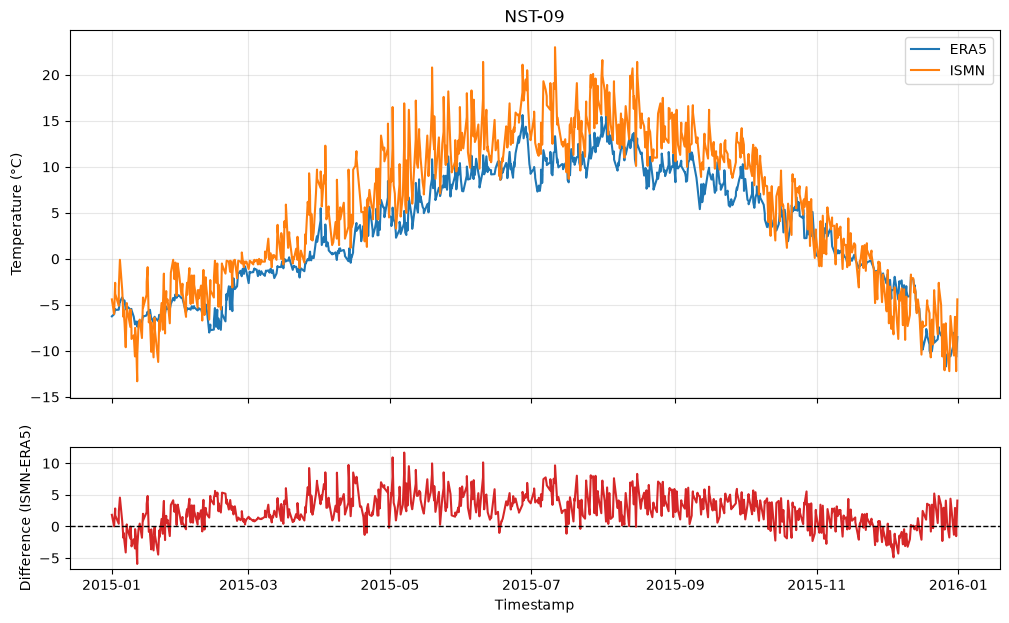

In [50]:
axes = plot_temp_differences(NST_09_era5_df, StationName.NST_09, start_date, end_date)

### 2.9 SOD012

In [51]:
SOD012_dfs = collect_cleaned_data(StationName.SOD012, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
SOD012_ascat_df, SOD012_era5_df = align_timestamps_then_label(SOD012_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

SOD012_ascat_df = SOD012_ascat_df.dropna()
SOD012_era5_df = SOD012_era5_df.dropna()

#### ASCAT

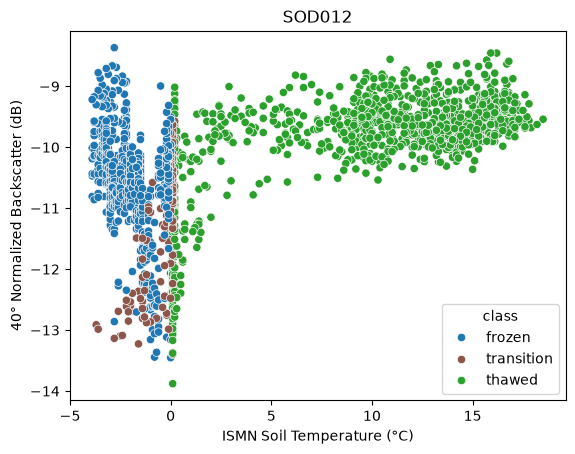

In [52]:
axes = plot_with_labels(SOD012_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.SOD012)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

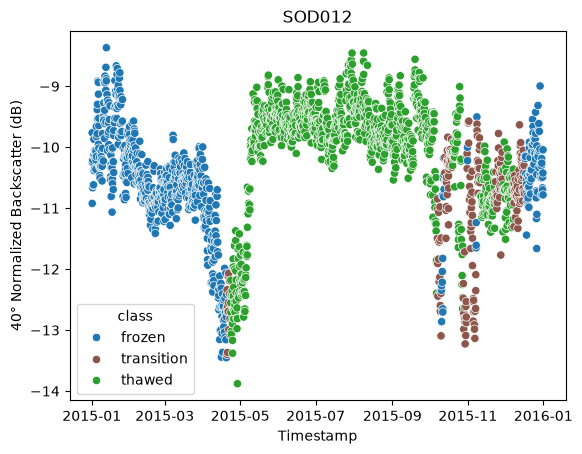

In [53]:
axes = plot_with_labels(SOD012_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.SOD012)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [54]:
SOD012_macro_f1, SOD012_transition_f1 = calculate_f1_scores(SOD012_era5_df["class"], SOD012_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.SOD012, SOD012_macro_f1, SOD012_transition_f1]

formatted_cm(SOD012_era5_df["class"], SOD012_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,6265,1737,0
transition,1004,397,74
thawed,3312,2788,11027


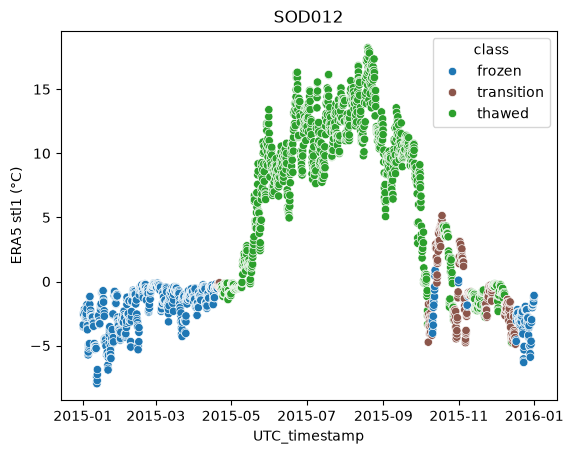

In [55]:
axes = plot_with_labels(SOD012_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.SOD012)
axes = axes.set_ylabel(era5_y_label)

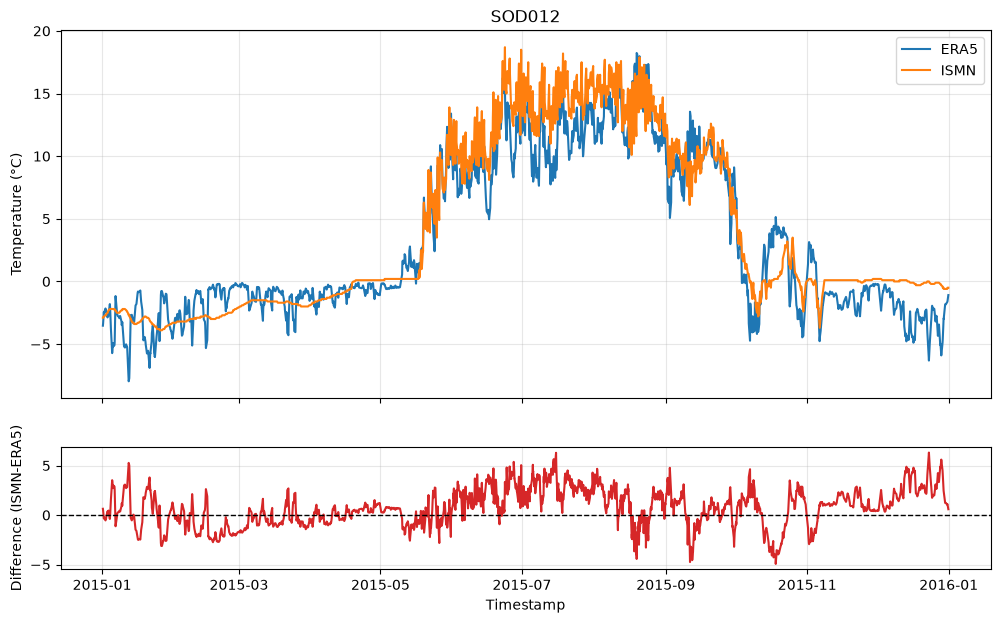

In [56]:
axes = plot_temp_differences(SOD012_era5_df, StationName.SOD012, start_date, end_date)

### 2.10 SOD103

In [57]:
SOD103_dfs = collect_cleaned_data(StationName.SOD103, c.CLEANED_DATA_PATH, c.DATETIMEINDEX_NAME)
SOD103_ascat_df, SOD103_era5_df = align_timestamps_then_label(SOD103_dfs, c.ISMN_LONG_VAR_NAME, c.ASCAT_KEY_COLS, c.ERA5_KEY_COLS)

SOD103_ascat_df = SOD103_ascat_df.dropna()
SOD103_era5_df = SOD103_era5_df.dropna()

#### ASCAT

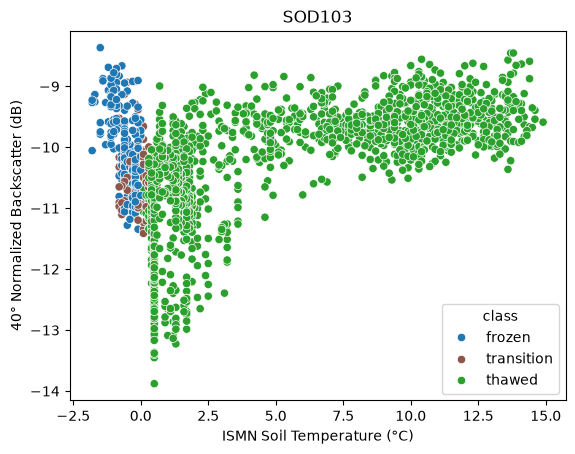

In [58]:
axes = plot_with_labels(SOD103_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date, x=c.ISMN_LONG_VAR_NAME)
axes.set_title(StationName.SOD103)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(ascat_x_label)

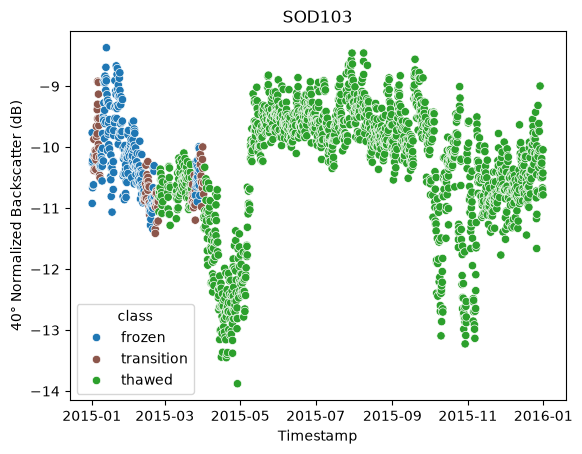

In [59]:
axes = plot_with_labels(SOD103_ascat_df, ascat_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.SOD103)
axes.set_ylabel(ascat_y_label)
axes = axes.set_xlabel(general_x_label)

#### ERA5

In [60]:
SOD0103_macro_f1, SOD0103_transition_f1 = calculate_f1_scores(SOD103_era5_df["class"], SOD103_era5_df["pred"], c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.SOD103, SOD0103_macro_f1, SOD0103_transition_f1]

formatted_cm(SOD103_era5_df["class"], SOD103_era5_df["pred"], c.CLASSES)

,frozen,transition,thawed
frozen,2093,232,0
transition,2183,405,6
thawed,6026,4188,10923


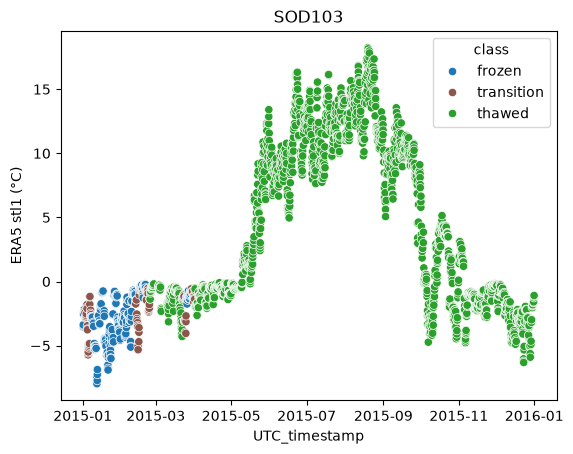

In [61]:
axes = plot_with_labels(SOD103_era5_df, era5_var_name, c.CLASSES, start_date, end_date)
axes.set_title(StationName.SOD103)
axes = axes.set_ylabel(era5_y_label)

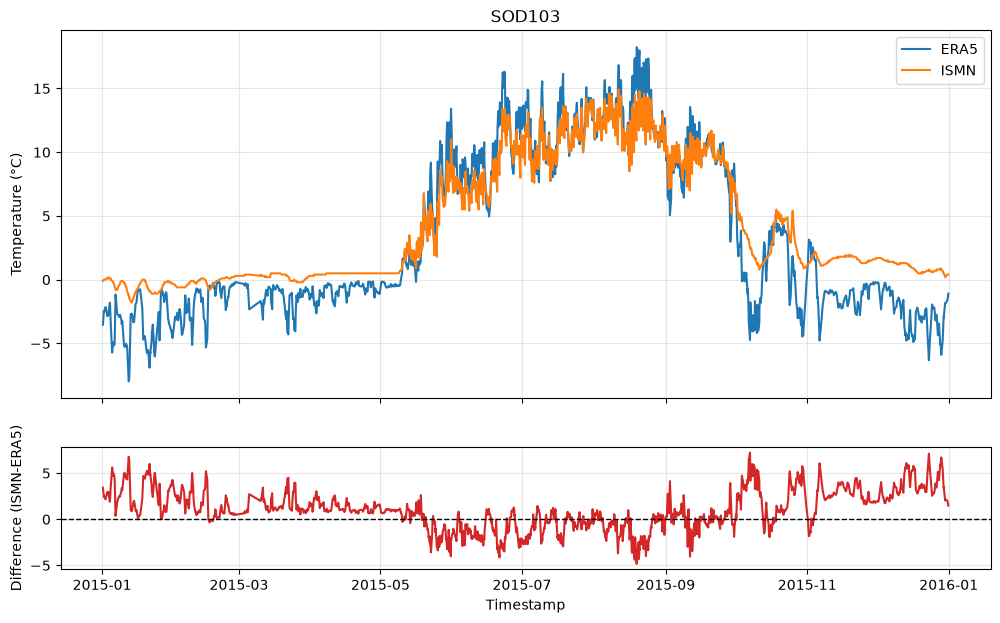

In [62]:
axes = plot_temp_differences(SOD103_era5_df, StationName.SOD103, start_date, end_date)

## 3. Summary

In [63]:
summary_df.loc[len(summary_df)] = ["Average", summary_df["Macro F1"].mean(), summary_df["Transition F1"].mean()]
summary_df

,Station,Macro F1,Transition F1
0,Aberdeen-35-WNW,0.588769,0.129278
1,Jamestown-38-WSW,0.570210,0.089623
2,GobblersKnob,0.650959,0.138184
3,Nenana,0.603429,0.046012
4,L23,0.514775,0.053486
5,L38,0.481471,0.023295
6,NST-07,0.711292,0.385075
7,NST-09,0.625885,0.294256
8,SOD012,0.526558,0.124121
9,SOD103,0.373991,0.109179


## 4. Conclusions

Overall, ERA5 did not align with the ISMN stations in predicting transition states in the soil. The lack of agreement in class labels appears to be due to large differences in the measured temperatures between the two methods, with differences reaching up to 20 &deg;C. In constrast, agreement is better for the frozen and thawed states since their definitions are more forgiving than the transition state.

The ASCAT plots of backscatter vs soil temperature suggest that an ML model trained on lagged features could perform well, especially if soil temperature clearly crosses the freezing point rather than oscillating. Such a model would likely perform best on Gobbler's Knob, Nenana, NST-07, and NST-09 since there's a clear break in the backscatter measurements around the freezing point.

The plots indicate that taking a single point measurement to compare against a large area measurement is not the most sound approach. The L, SOD, and NST networks have sensors clustered densely enough that they're covered by one ASCAT measurement footprint (assumed 23.7 km radius); other networks that were not included in this project could also be suitable. Future work could be to select multiple closely-packed sensors, taking an average of the soil temperature, then using this for labelling observations.